# Methods for Generating Random Variables

<a target="_blank" href="https://colab.research.google.com/github/JunyoungB/statistical-computing/blob/main/ch2.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In [31]:
import numpy as np

## Introduction

### Reproducible pseudo-random numbers

In [2]:
seed = 2026
rng = np.random.default_rng(seed)
u = rng.random(5) # Uniform(0,1)
u_ab = rng.uniform(2, 5, 5) # Uniform(2,5)

In [3]:
u, u_ab

(array([0.17893481, 0.63991317, 0.4672684 , 0.37050053, 0.35491733]),
 array([4.37155474, 4.71543151, 2.53205958, 3.95835441, 2.8949083 ]))

### With / without replacement

In [4]:
# toss some coins (0/1), with replacement
coins = rng.choice([0, 1], size=10, replace=True)

# choose 6 lottery numbers from 1..100, without replacement
lottery = rng.choice(np.arange(1, 101), size=6, replace=False)

In [5]:
coins, lottery

(array([0, 1, 1, 1, 0, 1, 1, 1, 0, 1]), array([64, 46, 44, 34, 80, 62]))

In [6]:
# permutation of letters a-z
letters = np.array(list("abcdefghijklmnopqrstuvwxyz"))
perm = rng.permutation(letters)

In [7]:
perm

array(['r', 'f', 's', 'p', 'o', 'a', 'd', 'h', 'k', 'x', 'q', 'v', 'm',
       'y', 'g', 'i', 'j', 'c', 'n', 'u', 'z', 'l', 't', 'e', 'w', 'b'],
      dtype='<U1')

In [8]:
from collections import Counter

# sample from a 3-category multinomial via categorical sampling
x = rng.choice([1, 2, 3], size=100, replace=True, p=[0.2, 0.3, 0.5])
counts = Counter(x) 

In [9]:
counts

Counter({np.int64(3): 54, np.int64(2): 31, np.int64(1): 15})

### Scipy convention

In [10]:
from scipy import stats

In [11]:
n, p = 10, 0.3
print(stats.binom.pmf(3, n, p))
print(stats.binom.cdf(3, n, p))
print(stats.binom.ppf(0.95, n, p))
print(stats.binom.rvs(n, p, size=5, random_state=seed))

0.2668279319999998
0.6496107184000002
5.0
[2 3 6 1 3]


## Inverse Transform Method

### Example: continuous inverse transform

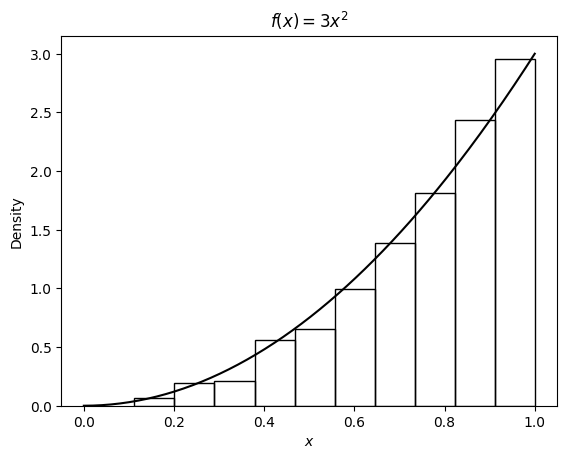

In [12]:
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed)
n = 1000

u = rng.random(n)
x = u ** (1/3)

# density histogram + theoretical density (black outline only)
plt.hist(x, bins=10, density=True, histtype="bar", facecolor="none", edgecolor="k")

y = np.linspace(0, 1, 200)
plt.plot(y, 3 * y**2, "k-", linewidth=1.5)

plt.xlabel(r"$x$")
plt.ylabel("Density")
plt.title(r"$f(x)=3x^2$")
plt.savefig("figs/2-1.png", dpi=160, bbox_inches='tight')

### Exponential distribution

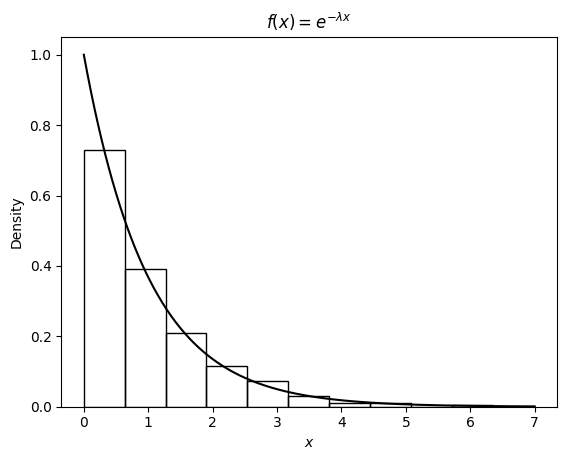

In [13]:
n = 1000
lam = 1.0

u = rng.random(n)
# avoid log(0) (rare but possible when u is extremely small)
u = np.clip(u, np.finfo(float).tiny, 1.0)

x = -np.log(u) / lam

plt.hist(x, bins=10, density=True, histtype="bar", facecolor="none", edgecolor="k")

y = np.linspace(0, 7, 500)
plt.plot(y, np.exp(-lam * y), "k-", linewidth=1.5)

plt.xlabel(r"$x$")
plt.ylabel("Density")
plt.title(r"$f(x)=e^{- \lambda x}$")
plt.show()

In [14]:
x = rng.exponential(scale=1/lam, size=n)

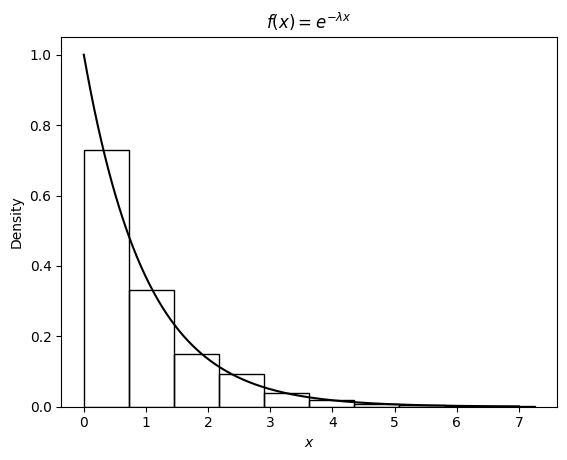

In [15]:
plt.hist(x, bins=10, density=True, histtype="bar", facecolor="none", edgecolor="k")

y = np.linspace(0, 7, 500)
plt.plot(y, np.exp(-lam * y), "k-", linewidth=1.5)

plt.xlabel(r"$x$")
plt.ylabel("Density")
plt.title(r"$f(x)=e^{- \lambda x}$")
plt.show()

### Example: discrete inverse transform

### Binomial Distribution

In [19]:
n = 1000
p = 0.4

u = rng.random(n)
x = (u > (1 - p)).astype(int)

# R's var() uses sample variance (ddof=1)
x_mean = x.mean()
x_var  = np.var(x, ddof=1)

print(x_mean, x_var)  # should be near p and p(1-p)

0.388 0.23769369369369375


In [20]:
# 1) Binomial with size=n
x1 = rng.binomial(n=1, p=p, size=n)
# 2) Categorical sampling from {0,1}
x2 = rng.choice([0, 1], size=n, replace=True, p=[1-p, p])

In [21]:
print(np.mean(x1), np.var(x1, ddof=1))
print(np.mean(x2), np.var(x2, ddof=1))

0.37 0.2333333333333333
0.414 0.24284684684684696


### Geometric Distribution

In [22]:
def rgeom_failures(n, p, seed=seed):
    rng = np.random.default_rng(seed)
    u = rng.random(n)
    u = np.clip(u, np.finfo(float).tiny, 1.0)
    return np.ceil(np.log(u) / np.log(1 - p)).astype(int) - 1

n = 100000
p = 0.25
x = rgeom_failures(n, p)

print(x.mean(), np.var(x, ddof=1))

3.02155 12.061306210562107


In [23]:
(1-p)/p, (1-p)/p**2

(3.0, 12.0)

## Acceptance-Rejection Method

### Acceptance-Rejection: Beta(2,2)

In [24]:
n = 1000
k = 0   # counter for accepted
j = 0   # iterations
y = np.empty(n, dtype=float)

while k < n:
    u = rng.random()
    j += 1
    x = rng.random()          # random variate from g = Uniform(0,1)
    if x * (1 - x) > u:
        y[k] = x
        k += 1

print(j)

5890


In [25]:
from scipy import stats

p = np.arange(0.1, 1.0, 0.1)

Qhat = np.quantile(y, p, method="linear")     # sample percentiles
Q = stats.beta.ppf(p, 2, 2)                   # theoretical percentiles

se = np.sqrt(p * (1 - p) / (n * stats.beta.pdf(Q, 2, 2)**2))

out = np.vstack([Qhat, Q, se])
print(np.round(out, 3))

[[0.19  0.278 0.352 0.426 0.493 0.554 0.624 0.708 0.796]
 [0.196 0.287 0.363 0.433 0.5   0.567 0.637 0.713 0.804]
 [0.01  0.01  0.01  0.011 0.011 0.011 0.01  0.01  0.01 ]]


## Transformation Methods

### Beta(3,2) via ratio of Gammas

In [28]:
n = 1000
a, b = 3.0, 2.0

# NumPy gamma uses shape=k and scale=theta (rate = 1/scale)
u = rng.gamma(shape=a, scale=1.0, size=n)
v = rng.gamma(shape=b, scale=1.0, size=n)

x = u / (u + v)  # Beta(a,b) sample

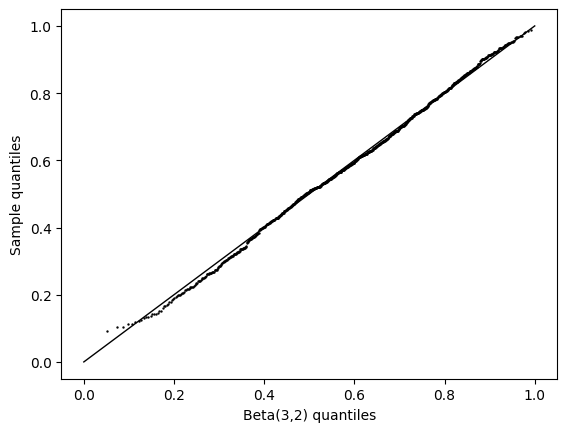

In [29]:
n = len(x)
p = (np.arange(1, n + 1) - 0.5) / n

q = stats.beta.ppf(p, a=3, b=2)     # theoretical quantiles
xs = np.sort(x)                    # ordered sample

plt.figure()
plt.scatter(q, xs, s=0.5, color="k")          # points: black, smaller
plt.plot([0, 1], [0, 1], "k-", linewidth=1) # line: black
plt.xlabel("Beta(3,2) quantiles")
plt.ylabel("Sample quantiles")
plt.savefig("figs/2-2.png", dpi=160, bbox_inches='tight')
plt.show()

## Sums and Mixtures

### Chi-square via sums of squrared normals

In [163]:
n = 1000
nu = 2

Z = rng.standard_normal(size=(n, nu))
X = Z**2
y = np.sum(X, axis=1)  # row sums

print(y.mean())
print((y**2).mean())

# theory: E[Y]=nu, Var(Y)=2*nu, so E[Y^2]=Var+mean^2 = 2nu + nu^2

1.9799188854957934
8.019335933049332


### Convolution vs Mixture of two Gammas

In [33]:
n = 1000

# R uses Gamma(shape, rate); NumPy uses Gamma(shape, scale=1/rate)
x1 = rng.gamma(shape=2.0, scale=1.0/2.0, size=n)  # Gamma(2, rate=2)
x2 = rng.gamma(shape=2.0, scale=1.0/4.0, size=n)  # Gamma(2, rate=4)

s = x1 + x2  # convolution

u = rng.random(n)
k = (u > 0.5).astype(int)          # 0/1 indicator
x = k * x1 + (1 - k) * x2          # mixture sample

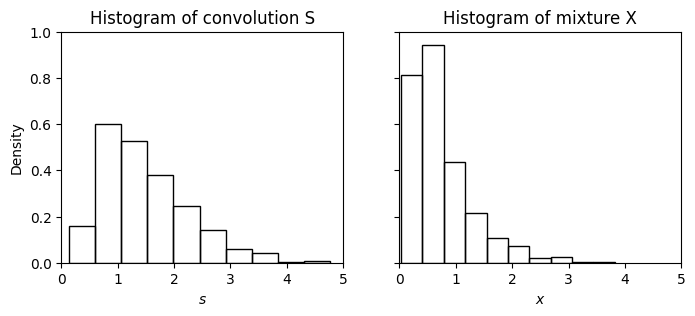

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharey=True)

axes[0].hist(s, bins=10, density=True, histtype="bar", facecolor="none", edgecolor="k")
axes[0].set_title("Histogram of convolution S")
axes[0].set_xlim(0, 5)
axes[0].set_ylim(0, 1)
axes[0].set_xlabel("$s$")
axes[0].set_ylabel("Density")

axes[1].hist(x, bins=10, density=True, histtype="bar", facecolor="none", edgecolor="k")
axes[1].set_title("Histogram of mixture X")
axes[1].set_xlim(0, 5)
axes[1].set_ylim(0, 1)
axes[1].set_xlabel("$x$")

plt.savefig("figs/2-3.png", dpi=160, bbox_inches='tight')
plt.show()

### Mixture of several Gammas

In [35]:
n = 5000

weights = np.arange(1, 6) / 15.0              # w_j = j/15
k = rng.choice(np.arange(1, 6), size=n, p=weights)  # {1,...,5}
rate = 1.0 / k                                 # lambda_j = 1/j
x = rng.gamma(shape=3.0, scale=1.0/rate)        # scale = 1/rate

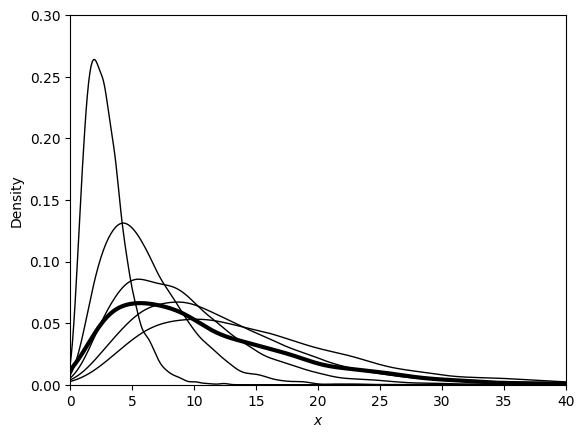

In [36]:
from scipy.stats import gaussian_kde

grid = np.linspace(0, 40, 400)

kde_mix = gaussian_kde(x)
plt.plot(grid, kde_mix(grid), linewidth=3, label="mixture (KDE)", color='k')

# component KDE curves (thin)
for j in range(1, 6):
    xj = rng.gamma(shape=3.0, scale=j, size=n)  # rate=1/j => scale=j
    kde_j = gaussian_kde(xj)
    plt.plot(grid, kde_j(grid), linewidth=1, color='k')

plt.ylim(0, 0.3); plt.xlim(0, 40)
plt.xlabel("$x$"); plt.ylabel("Density")
plt.savefig("figs/2-4.png", dpi=160, bbox_inches='tight')
plt.show()

## Multivariate Distributions

### MVN generator via eigen decomposition

In [37]:
def rmvn_eigen(n, mu, Sigma, seed=seed):
    rng = np.random.default_rng(seed)
    mu = np.asarray(mu, dtype=float)
    Sigma = np.asarray(Sigma, dtype=float)
    d = mu.size

    # eigen-decomposition for symmetric matrices
    vals, vecs = np.linalg.eigh(Sigma)
    Q = vecs @ np.diag(np.sqrt(vals)) @ vecs.T      # Sigma^(1/2)
    Z = rng.standard_normal(size=(n, d))            # N(0, I)
    X = Z @ Q + mu                                  # broadcast adds mu to each row
    return X

sample mean: [-0.0402306  -0.05404689]
sample corr:
 [[1.         0.90167994]
 [0.90167994 1.        ]]


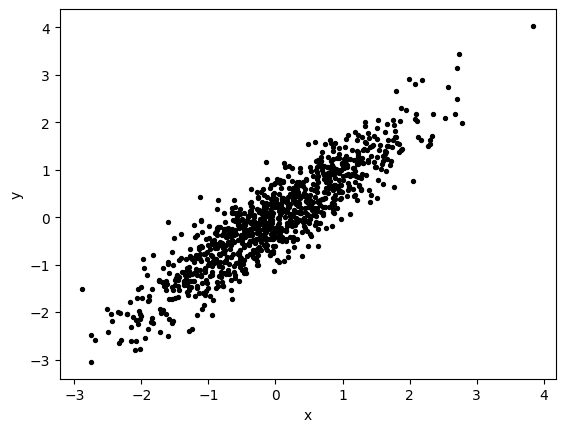

In [38]:
mu = np.array([0.0, 0.0])
Sigma = np.array([[1.0, 0.9],
                  [0.9, 1.0]])

X = rmvn_eigen(1000, mu, Sigma, seed)

print("sample mean:", X.mean(axis=0))
print("sample corr:\n", np.corrcoef(X.T))

plt.figure()
plt.scatter(X[:, 0], X[:, 1], s=8, c='k')
plt.xlabel("x"); plt.ylabel("y")
plt.savefig("figs/2-5.png", dpi=160, bbox_inches='tight')
plt.show()

### MVN generator via SVD

In [39]:
def rmvn_svd(n, mu, Sigma, seed):
    rng = np.random.default_rng(seed)
    mu = np.asarray(mu, dtype=float)
    Sigma = np.asarray(Sigma, dtype=float)
    d = mu.size

    U, s, Vt = np.linalg.svd(Sigma)
    Q = U @ np.diag(np.sqrt(s)) @ Vt               # Sigma^(1/2)

    Z = rng.standard_normal(size=(n, d))
    X = Z @ Q + mu
    return X

### MVN generator via Cholesky

In [40]:
def rmvn_cholesky(n, mu, Sigma, seed):
    rng = np.random.default_rng(seed)
    mu = np.asarray(mu, dtype=float)
    Sigma = np.asarray(Sigma, dtype=float)
    d = mu.size

    L = np.linalg.cholesky(Sigma)  # Sigma = L L^T
    Q = L.T                        # so that Q^T Q = Sigma

    Z = rng.standard_normal(size=(n, d))
    X = Z @ Q + mu
    return X

### Mixture of Multivariate Normals

In [41]:
def mvn_loc_mix(n, p, mu1, mu2, Sigma, seed):
    rng = np.random.default_rng(seed)
    mu1 = np.asarray(mu1, dtype=float)
    mu2 = np.asarray(mu2, dtype=float)

    n1 = rng.binomial(n, p)
    n2 = n - n1

    x1 = rng.multivariate_normal(mean=mu1, cov=Sigma, size=n1)
    x2 = rng.multivariate_normal(mean=mu2, cov=Sigma, size=n2)

    X = np.vstack([x1, x2])
    idx = rng.permutation(n)
    return X[idx, :]

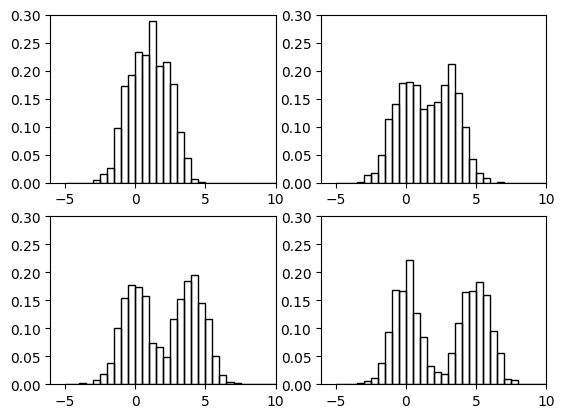

In [42]:
n = 1000; p = 0.5
mu1 = np.zeros(4); mu2 = np.array([2, 3, 4, 5]); Sigma = np.eye(4)

X = mvn_loc_mix(n, p, mu1, mu2, Sigma, seed=seed)

rmin, rmax = X.min(), X.max()
pad = 0.2 * (rmax - rmin)
xlim = (rmin - pad, rmax + pad)

fig, axes = plt.subplots(2, 2); axes = axes.ravel()
for i in range(4):
    ax = axes[i]
    ax.hist(X[:, i], bins=np.arange(-5, 10.5, 0.5), density=True, facecolor="none", edgecolor="k")
    ax.set_xlim(*xlim); ax.set_ylim(0, 0.3)
plt.savefig("figs/2-6.png", dpi=160, bbox_inches='tight')
plt.show()

### Uniform Distribution on the $d$-sphere

In [43]:
def runif_sphere(n, d, seed):
    rng = np.random.default_rng(seed)
    M = rng.standard_normal(size=(n, d))
    norms = np.linalg.norm(M, axis=1, keepdims=True)
    U = M / norms
    return U

X = runif_sphere(200, 2, seed=seed)
print(X.shape)                 # (200, 2)
print(np.linalg.norm(X, axis=1).min(), np.linalg.norm(X, axis=1).max())  # ~1

(200, 2)
0.9999999999999998 1.0000000000000002


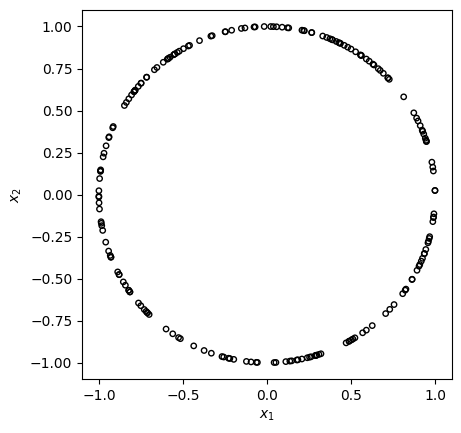

In [44]:
X = runif_sphere(200, 2, seed)

plt.scatter(X[:, 0], X[:, 1], s=15, facecolor="none", edgecolor="k")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.gca().set_aspect("equal", adjustable="box")  # makes the circle round
plt.savefig("figs/2-7.png", dpi=160, bbox_inches='tight')
plt.show()